# 库导入

In [3]:
# 库索引
import numpy as np
import matplotlib.pyplot as plt
#%matplotlib inline
from astropy.cosmology import FlatLambdaCDM
from astropy import constants as const
#import camb
#from camb import model, initialpower
from scipy.integrate import quad

#import mpmath as mp
import astropy.units as u
from astropy.cosmology import z_at_value
import pickle
from matplotlib.ticker import FuncFormatter # 图表格式化库

from typing import Tuple # 类型提示库
import pandas as pd # 使用pandas读取信息

from gapp import dgp # GP拟合方法库

import csv
from scipy.interpolate import interp1d

from pycbc.waveform import get_fd_waveform, get_fd_waveform_sequence
from pycbc.types import TimeSeries,FrequencySeries, Array




# 全局常量初始化

In [4]:
# 定义全局常量
np.random.seed(202506012)
# 光速
c_light=const.c.to(u.km/u.s).value  # 定义天文学中的光速
c_mpc_yr=const.c.to(u.Mpc/u.yr) # 将光速转化为Mpc/year 的情况

# 万有引力常数
constG=const.G.to(u.Mpc**3/(u.Msun*u.s**2)).value # 是万有引力常数
constc=const.c.to(u.Mpc/u.s).value # 转换换单位为 Mpc³ / (Msun·s²)，方便天体物理和宇宙学单位下使用
 
#ACDM标准宇宙学模型=cosmo内储存了一些常量+cosmo可以计算很多宇宙学（依据其所储存的常量）量
cosmo=FlatLambdaCDM(H0=67.64,Om0=0.3087)

In [6]:
# 数据CSV文件读取并输出
# 输入：CSV文件路径 -> 输出：原始数据的NumPy数组data_array[][]
def read_csv_to_numpy(file_path: str) -> np.ndarray:
    df = pd.read_csv(file_path)  # 文件路径可以是相对路径或绝对路径
    data_array = df.to_numpy()
    return data_array # 这里返回的是一个二维Numpy数组

In [7]:
# 绘制二维数组[][2]数据直方图
# 输入：(二维数组data_array[..][3], 图例标签，点线样式，误差条颜色) -> 输出：无（一个待打印的图）
# def plot_histogram_from_csv(file_path: str):
def plot_histogram_from_csv(file_path, z_min=None, z_max=None, bins=10):
    data = read_csv_to_numpy(file_path)  # 替换成你的文件路径

    z = data[:, 0]  # 假设 z 在第一列
    cnt = data[:, 1]  # 假设 cnt 在第二列

    # 自动设置 z 范围
    if z_min is None:
        z_min = z.min()
    if z_max is None:
        z_max = z.max()

    # 生成 bin 边界
    bin_edges = np.linspace(z_min, z_max, bins + 1)

    # 统计每个 bin 的总计数
    hist, _ = np.histogram(z, bins=bin_edges, weights=cnt)

    # 绘制直方图
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    width = bin_edges[1] - bin_edges[0]

    plt.figure(figsize=(10,6))
    plt.bar(bin_centers, hist, width=width, color='skyblue', edgecolor='black')
    plt.xlim(0,0.5)
    plt.ylim(bottom=0)
    plt.xlabel('z')
    plt.ylabel('Count')
    plt.title(f'Histogram of counts vs z (bins={bins})')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    # 绘制直方图，按 z 的区间统计，cnt 用作权重
    # plt.figure(figsize=(10,6))

    # # 这里用 bins=10，你可以根据需要调整区间数
    # plt.hist(z, bins=10, weights=cnt, color='skyblue', edgecolor='black')

    # plt.xlabel('z')
    # plt.ylabel('Count')
    # plt.title('Histogram of counts vs z')
    # plt.grid(axis='y', linestyle='--', alpha=0.7)
    # plt.show()

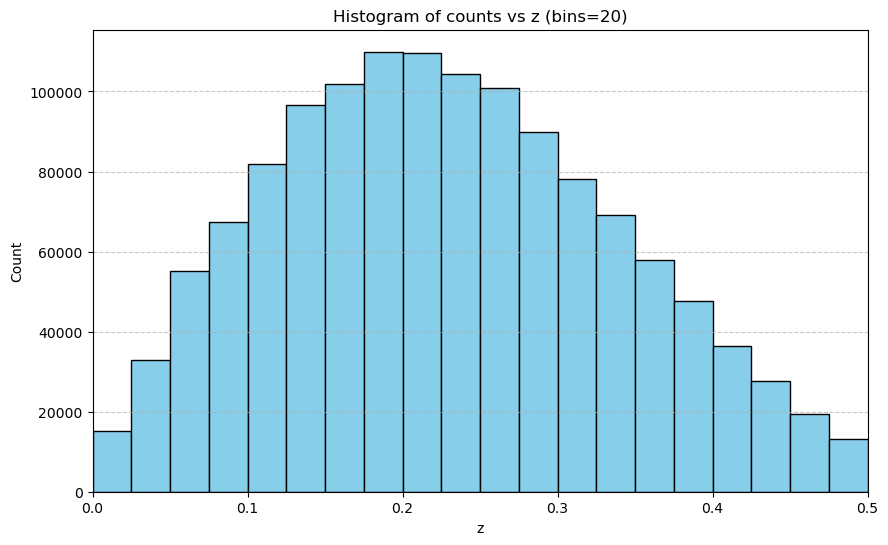

In [23]:
plot_histogram_from_csv("Data/results_histogram.csv",0,0.5,20)

In [9]:
def stratified_sampling_from_histogram(csv_file, output_file, N_total, z_min=None, z_max=None, bins=10, seed=None):
    """
    从直方图 CSV 文件进行加权分层抽样
    csv_file: 输入 CSV 文件，包含 'z' 和 'cnt' 两列，z 为条形中值
    output_file: 输出 CSV 文件
    N_total: 总共要抽取的样本数
    z_min, z_max: 可选，定义直方图 z 范围
    bins: 分箱数（可选）
    seed: 随机种子（可选）
    """
    if seed is not None:
        np.random.seed(seed)
    
    # 读取 CSV
    df = pd.read_csv(csv_file)
    z = df['z'].values
    cnt = df['cnt'].values

    # 设置 z 范围
    if z_min is None:
        z_min = z.min()
    if z_max is None:
        z_max = z.max()

    # 生成 bin 边界
    bin_edges = np.linspace(z_min, z_max, bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    width = bin_edges[1] - bin_edges[0]

    # 按 bin 中心找到每个 z 属于哪一个 bin
    bin_indices = np.digitize(z, bin_edges) - 1
    bin_indices[bin_indices == bins] = bins - 1  # 边界处理

    # 计算每个 bin 的总权重
    bin_weights = np.zeros(bins)
    for i, w in zip(bin_indices, cnt):
        bin_weights[i] += w

    # 根据权重分配样本数（四舍五入）
    bin_sample_counts = np.round(N_total * bin_weights / bin_weights.sum()).astype(int)

    # 在每个 bin 内随机生成样本
    samples = []
    for i, n_samples in enumerate(bin_sample_counts):
        if n_samples > 0:
            # 均匀分布在 bin 区间
            s = np.random.uniform(bin_edges[i], bin_edges[i+1], n_samples)
            samples.append(s)
    samples = np.concatenate(samples)

    # 保存到 CSV
    pd.DataFrame({'z_sampled': samples}).to_csv(output_file, index=False)
    print(f"生成 {len(samples)} 个样本，已保存到 {output_file}")


In [10]:
# stratified_sampling_from_histogram(
#     csv_file="Data/results_histogram.csv",
#     output_file="sampled_points.csv",
#     N_total=5000,
#     z_min=0,
#     z_max=0.5,
#     bins=10,
#     seed=42
# )

In [11]:
# 

# 波形$h$部分

## 探测器

### 探测器灵敏度曲线

In [50]:
# 得到Sn的PSD插值函数形式
# 主要输入：探测器名字 -> 输出：一个Sn的PSD插值
def get_detector_psd(detector="LISA"):
    """
    返回指定探测器的噪声 PSD 插值函数
    输入:
        detector: 探测器类型, 支持 "LISA", "TianQin", "aLIGO"
        c_light: 光速 (km/s)
    返回:
        interp_psd(f): 可调用函数, 输入频率 f (Hz), 返回幅度谱 sqrt(Sn(f))
    """

    # 频率数组
    f_array = np.arange(1e-4, 1.0, 0.0001)  # 可根据探测器调整范围

    if detector == "LISA":
        # ------------------ LISA PSD ------------------
        # 加速度噪声
        Sacc = 9e-30 * 1e-6 / (2*np.pi*f_array)**4 * (1 + (6e-4/f_array)**2 * (1 + (2.22e-5/f_array)**8)) 
        
        # 其他噪声
        Sother = 8.899e-23 * 1e-6

        A = 3/20 * 3.2665e-44
        s1, alpha = 3014.3, 1.183
        s2, kappa = 2957.7, 2.0928e-3
        
        # 混合白矮星背景噪声 
        Sconf = A/2 * np.exp(-s1*f_array**alpha) * f_array**(-7/3) * (1 - np.tanh(s2*(f_array - kappa)))
        L = 2.5e6

        # 总噪声
        Sn_total = (4*Sacc + Sother)/L**2 * (1 + (2*f_array*L/(0.41*c_light))**2) + Sconf

    elif detector == "TianQin":
        # ------------------ TianQin PSD ------------------
        L = 1.73e5  # km
        Sacc = (3e-15)**2 * (1 + (0.4e-3/f_array)**2) * (1 + (f_array/0.008)**4)
        Sother = (1e-12)**2
        Sn_total = (20/(3*L**2)) * (Sother + 4*Sacc/(2*np.pi*f_array)**4)

    elif detector == "aLIGO":
        # ------------------ aLIGO PSD 简化版 ------------------
        f0 = 215.0
        x = f_array / f0
        Sn_total = 1e-49 * (x**(-4.14) - 5*x**(-2) + 111*(1 - x**2 + x**4/2)/(1 + x**2/2))

    else:
        raise ValueError(f"Unknown detector type: {detector}")
    
    # 幅度谱
    psd = np.sqrt(Sn_total)
    psd_array = np.column_stack((f_array, psd))
    # 返回插值函数
    return lambda f: np.interp(f, psd_array[:,0], psd_array[:,1])


def Sacc(f):
    return 9*10**(-30)*10**(-6)/(2*np.pi*f)**4*(1+(6*10**(-4)/f)**2*(1+(2.22*10**(-5)/f)**8))

def Sother(f):
    return 8.899*10**(-23)*10**(-6)

def Sconf(f):
    A=3/20*3.2665*10**(-44)
    s1=3014.3
    alpha=1.183
    s2=2957.7
    kappa=2.0928*10**(-3)
    return A/2*np.exp(-s1*f**alpha)*f**(-7/3)*(1-np.tanh(s2*(f-kappa)))

def Sn(f):
    L=2.5*10**6
    return (4*Sacc(f)+Sother(f))/L**2*(1+(2*f*L/(0.41*c_light))**2)+Sconf(f)


### 探测器响应函数

In [51]:
# 根据探测器类型生成响应函数
# 输入 : 探测器名字 -> 输出 : 多个函数和一个数值组成的字典
def get_detector_response(detector="LISA"):
    """
    根据探测器类型返回相应的时频关系和响应函数
    输入:
        detector: 探测器名称, 支持 "LISA", "TianQin" (可扩展)
    返回:
        fm: 调制频率 (Hz)
        tf_func: 时频关系函数 tf(tc, f, Mc)
        tfe_func: 考虑偏心率的时频函数 tfe(tc, f, Mc)
        alphat_func: 调制相位函数 alphat(t)
        Dp_func: 极化响应 Dp(t, theta, phi, lam)
        Dc_func: 极化响应 Dc(t, theta, phi, lam)
        Fp_func: 幅度响应 F+ (f, Mc, theta, phi, psi, tc, lam)
        Fc_func: 幅度响应 Fx (f, Mc, theta, phi, psi, tc, lam)
    """

    # ---------------- 分支选择 ----------------
    if detector == "LISA":
        fm = 1/((1*u.yr).to(u.s).value)  # LISA 基本调制频率

        # 时频关系函数
        def tf(tc, f, Mc):
            return tc - 5*(8*np.pi*f)**(-8/3) * (constG*Mc)**(-5/3) * constc**5

        def tfe(tc, f, Mc):
            poly = (3.35699e-55 - 7.50015e-50*f + 3.99113e-45*f**2 + 4.33106e-40*f**3
                    - 7.76808e-35*f**4 + 5.32154e-30*f**5 - 2.0606e-25*f**6 + 4.75385e-21*f**7
                    - 6.04605e-17*f**8 + 2.66042e-13*f**9 + 1.85397e-9*f**10
                    - 2.02688e-8*f**11 - 0.375*f**12)
            return tc + 5*constG*Mc/(96*(np.pi*constG*Mc)**(8/3))*constc**5*poly/f**(44/3)

    elif detector == "TianQin":
        fm = 1/(365*u.day.to(u.s))  # TianQin 基本调制频率
        # 可以定义专门的时频关系，下面用LISA形式占位
        def tf(tc, f, Mc):
            return tc - 5*(8*np.pi*f)**(-8/3) * (constG*Mc)**(-5/3) * constc**5

        def tfe(tc, f, Mc):
            poly = (3.35699e-55 - 7.50015e-50*f + 3.99113e-45*f**2 + 4.33106e-40*f**3
                    - 7.76808e-35*f**4 + 5.32154e-30*f**5 - 2.0606e-25*f**6 + 4.75385e-21*f**7
                    - 6.04605e-17*f**8 + 2.66042e-13*f**9 + 1.85397e-9*f**10
                    - 2.02688e-8*f**11 - 0.375*f**12)
            return tc + 5*constG*Mc/(96*(np.pi*constG*Mc)**(8/3))*constc**5*poly/f**(44/3)

    else:
        raise ValueError(f"Unknown detector type: {detector}")

    # ---------------- 通用响应函数 ----------------
    def alphat(t):
        return 2*np.pi*fm*t - 1/12*np.pi

    def Dp(t, theta, phi, lam):
        factor = np.sqrt(3)/64
        term1 = -36*np.sin(theta)**2 * np.sin(2*alphat(t) - 2*lam)
        term2 = (3 + np.cos(2*theta)) * (
            np.cos(2*phi)*(9*np.sin(2*lam) - np.sin(4*alphat(t)-2*lam)) +
            np.sin(2*phi)*(np.cos(4*alphat(t)-2*lam)-9*np.cos(2*lam))
        )
        term3 = -4*np.sqrt(3)*np.sin(2*theta) * (
            np.sin(3*alphat(t)-2*lam-phi) - 3*np.sin(alphat(t)-2*lam+phi)
        )
        return factor * (term1 + term2 + term3)

    def Dc(t, theta, phi, lam):
        factor = 1/16
        term1 = np.sqrt(3)*np.cos(theta)*(9*np.cos(2*lam-2*phi) - np.cos(4*alphat(t)-2*lam-2*phi))
        term2 = -6*np.sin(theta)*(np.cos(3*alphat(t)-2*lam-phi) + 3*np.cos(alphat(t)-2*lam+phi))
        return factor * (term1 + term2)

    def Fp(f, Mc, theta, phi, psi, tc, lam):
        return 0.5*(np.cos(2*psi)*Dp(tf(tc,f,Mc), theta, phi, lam) - 
                    np.sin(2*psi)*Dc(tf(tc,f,Mc), theta, phi, lam))

    def Fc(f, Mc, theta, phi, psi, tc, lam):
        return 0.5*(np.sin(2*psi)*Dp(tf(tc,f,Mc), theta, phi, lam) + 
                    np.cos(2*psi)*Dc(tf(tc,f,Mc), theta, phi, lam))

    return {
        "fm": fm,
        "tf": tf,
        "tfe": tfe,
        "alphat": alphat,
        "Dp": Dp,
        "Dc": Dc,
        "Fp": Fp,
        "Fc": Fc
    }

# 调用实例
# resp = get_detector_response("LISA")
# # 调用频率
# print(resp["fm"])
# # 调用函数
# tc, f, Mc = 0.0, 1e-3, 1.2e30
# t_coal = resp["tf"](tc, f, Mc)

## 生成频域波形(需要使用响应函数)

### 时间延迟函数

In [52]:
#时间延迟推导，引力波到达太阳和
# 主要输入: 物理量参数+探测器名字 -> 输出:返回意味数组
L=2.5*10**9. #meter
R=(1*u.AU).to(u.m).value
eob=L/(2*np.sqrt(3)*R)

def delay(tc,f,Mc,theta,phi,detector="LISA"):
    resp = get_detector_response(detector=detector)
    t=resp["tf"](tc,f,Mc)
    alpha=resp["alphat"](t)
    dl=-R*np.cos(alpha-phi)*np.sin(theta)+eob*(np.sqrt(3)*R*np.cos(alpha)*np.cos(theta)-1/2*R*((np.cos(2*alpha-phi)-3*np.cos(phi))*np.sin(theta)))
    return dl/const.c.value


### 频域波形生成

In [81]:
# 生成频域波形hf
# 主要输入: 各种参数+探测器名字 -> 输出 一维频率数组（Hz） + 对应频率的复数引力波信号 一维数组
def hf(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,kappa,lam,detector="LISA"): 
  resp = get_detector_response("LISA")

  fmin=10**(-4)
  m1=(Mc*eta**(2/5)+np.sqrt((1-4*eta)*eta**(4/5)*Mc**2))/(2*eta)
  m2=(Mc*eta**(2/5)-np.sqrt((1-4*eta)*eta**(4/5)*Mc**2))/(2*eta)
  fmax=constc**3/(6*np.sqrt(6)*np.pi*constG*(Mc/eta**(3/5)))
  f_end=np.min([fmax,0.1])

  apx=   'TaylorF2' #'IMRPhenomD'  
  hp, hc = get_fd_waveform(approximant=apx,
    mass1=m1,
    mass2=m2,
    delta_f=10**(-5),
    distance=dL,
    coa_phase=phic,
    inclination=iota,
    f_lower=fmin,
    f_final=f_end             
    )
       
  flist = np.array(hp.sample_frequencies[10:])
  hplist = np.array(hp[10:])
  hclist = np.array(hc[10:])
  h0=hplist*resp["Fp"](flist,Mc,theta,phi,psi,tc,lam)+hclist*resp["Fc"](flist,Mc,theta,phi,psi,tc,lam)
  t0=tc+delay(tc,flist,Mc,theta,phi,detector) 
  h=h0*np.exp(-1j*2*np.pi*flist*t0)

  # wave = np.column_stack((flist,h)) 
  # wave[:,0] = np.real(wave[:,0])
  # return wave

  # 创建结构化数组，明确指定数据类型
  dtype = [('freq', 'f8'), ('h', 'complex128')]
  wave = np.zeros(len(flist), dtype=dtype)
  wave['freq'] = flist
  wave['h'] = h
  return wave



# 根据波形和噪声曲线计算信噪比和Fisher矩阵

## 信噪比

### 计算信噪比

In [82]:
# 计算信噪比
# 输入: 物理量参数 -> 输出 : 信噪比数值
def rho2_test(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,kappa,lam,detector="LISA"):

    wave = hf(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,kappa,lam,detector)
    flist1 =wave['freq'] 
    hlist1=wave['h']
    Snd = get_detector_psd(detector="LISA")
    psd = Snd(flist1)

    rho2i0=4*abs(hlist1)**2/psd**2

    # 梯形法进行积分
    rho2i1=rho2i0[:-1]
    rho2i2=rho2i0[1:]
    rho2i=(rho2i1+rho2i2)/2*(flist1[1]-flist1[0])
    return np.sum(rho2i)

### 生成带有信噪比数据的数组 并根据信噪比进行筛选

In [109]:
# 载入数据
data = np.loadtxt('Data/samQ3d.txt')
z=data[:,0]
m1=data[:,1]
m2=data[:,2]
Mc=data[:,3]
eta=data[:,4]
dL=data[:,5]
iota=data[:,6]
theta=data[:,7]
phi=data[:,8]
psi=data[:,9]

# wave = hf(Mc[0],eta[0],dL[0],iota[0],theta[0],phi[0],psi[0],0,0,0,0,0,detector="LISA")
# print(wave)

In [110]:
def GW_with_SNR(detector="LISA"):
    snr=[]
    for i in range(len(z)):
        snr1=rho2_test(Mc[i],eta[i],dL[i],iota[i],theta[i],phi[i],psi[i],0,0,0,0,0,detector)
        snr2=rho2_test(Mc[i],eta[i],dL[i],iota[i],theta[i],phi[i],psi[i],0,0,0,0,np.pi/4,detector)
        snr_1=np.sqrt(snr1+snr2)
        snr.append(snr_1)
    return snr


In [ ]:
#生成包含信噪比的GW事件列表，并且筛选信噪比大于一定值的事件
snr = GW_with_SNR(detector="LISA")
GWlist=np.column_stack((z,snr,m1,m2,Mc,eta,dL,iota,theta,phi,psi))
GWlist_12=GWlist[GWlist[:,1]>12]


header = "z,SNR,m1,m2,Mc,eta,dL,iota,theta,phi,psi"
# 保存为CSV文件
np.savetxt('GWlist_12.csv', GWlist_12, 
           delimiter=',', header=header, comments='', fmt='%.6f')

/tmp/ipykernel_3707/2924259640.py:24: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  flist = np.array(hp.sample_frequencies[10:])
/tmp/ipykernel_3707/2924259640.py:25: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  hplist = np.array(hp[10:])
/tmp/ipykernel_3707/2924259640.py:26: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migratio

## Fisher矩阵与 $\Delta d_L$

In [ ]:
#fisher matrix微分，注意不同质量范围的源步长选取可能不同
def ph0(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,kappa,lam):
    dMc=Mc*10**-11
    result_plus = hf(Mc+dMc,eta,dL,iota,theta,phi,psi,tc,phic,e0,kappa,lam)
    result_minus = hf(Mc-dMc,eta,dL,iota,theta,phi,psi,tc,phic,e0,kappa,lam)
    dh = result_plus['h'] - result_minus['h']
    return dh/(2*dMc)

def ph1(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,kappa,lam):
    deta=10**-11  
    result_plus = hf(Mc,eta+deta,dL,iota,theta,phi,psi,tc,phic,e0,kappa,lam)
    result_minus = hf(Mc,eta-deta,dL,iota,theta,phi,psi,tc,phic,e0,kappa,lam)
    dh = result_plus['h'] - result_minus['h']
    return dh/(2*deta)

def ph2(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,kappa,lam):
    ddL=10**-6
    result_plus = hf(Mc,eta,dL+ddL,iota,theta,phi,psi,tc,phic,e0,kappa,lam)
    result_minus = hf(Mc,eta,dL-ddL,iota,theta,phi,psi,tc,phic,e0,kappa,lam)
    dh = result_plus['h'] - result_minus['h']
    return dh/(2*ddL)

def ph3(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,kappa,lam):
    diota=10**-8
    result_plus = hf(Mc,eta,dL,iota+diota,theta,phi,psi,tc,phic,e0,kappa,lam)
    result_minus = hf(Mc,eta,dL,iota-diota,theta,phi,psi,tc,phic,e0,kappa,lam)
    dh = result_plus['h'] - result_minus['h']
    return dh/(2*diota)/(-np.sin(iota))

def ph4(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,kappa,lam):
    dtheta=10**-9
    result_plus = hf(Mc,eta,dL,iota,theta+dtheta,phi,psi,tc,phic,e0,kappa,lam)
    result_minus = hf(Mc,eta,dL,iota,theta-dtheta,phi,psi,tc,phic,e0,kappa,lam)
    dh = result_plus['h'] - result_minus['h']
    return dh/(2*dtheta)

def ph5(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,kappa,lam):
    dphi=10**-9
    result_plus = hf(Mc,eta,dL,iota,theta,phi+dphi,psi,tc,phic,e0,kappa,lam)
    result_minus = hf(Mc,eta,dL,iota,theta,phi-dphi,psi,tc,phic,e0,kappa,lam)
    dh = result_plus['h'] - result_minus['h']
    return dh/(2*dphi)

def ph6(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,kappa,lam):
    dpsi=10**-9
    result_plus = hf(Mc,eta,dL,iota,theta,phi,psi+dpsi,tc,phic,e0,kappa,lam)
    result_minus = hf(Mc,eta,dL,iota,theta,phi,psi-dpsi,tc,phic,e0,kappa,lam)
    dh = result_plus['h'] - result_minus['h']
    return dh/(2*dpsi)

def ph7(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,kappa,lam):
    dtc=10**-6  
    result_plus = hf(Mc,eta,dL,iota,theta,phi,psi,tc+dtc,phic,e0,kappa,lam)
    result_minus = hf(Mc,eta,dL,iota,theta,phi,psi,tc-dtc,phic,e0,kappa,lam)
    dh = result_plus['h'] - result_minus['h']
    return dh/(2*dtc)

def ph8(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,kappa,lam):
    dphic=10**-6
    result_plus = hf(Mc,eta,dL,iota,theta,phi,psi,tc,phic+dphic,e0,kappa,lam)
    result_minus = hf(Mc,eta,dL,iota,theta,phi,psi,tc,phic-dphic,e0,kappa,lam)
    dh = result_plus['h'] - result_minus['h']
    return dh/(2*dphic)

# 偏心率部分
# def ph9(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,kappa,lam):
#     de0=10**-10
#     dh=hf(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0+de0,kappa,lam)[1]-hf(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0-de0,kappa,lam)[1]
#     return dh/(2*de0)

phmat=np.array([ph0,ph1,ph2,ph3,ph4,ph5,ph6,ph7,ph8])

#fisher矩阵计算
def Gamma(i,j,Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,kappa,lam):
    wave =hf(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,kappa,lam,detector="LISA")
    flist=wave['freq']
    ri=phmat[i](Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,kappa,lam).real
    rj=phmat[j](Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,kappa,lam).real
    imgi=phmat[i](Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,kappa,lam).imag
    imgj=phmat[j](Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,kappa,lam).imag
    gammaijbin0=4*(ri*rj+imgi*imgj)/Sn(flist)
    gammaijbin1=gammaijbin0[:-1]
    gammaijbin2=gammaijbin0[1:]
    gammaijbin=(gammaijbin1+gammaijbin2)/2*(flist[1]-flist[0])
    return np.sum(gammaijbin)

def FM(Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,kappa,lam):
    fisher=np.zeros((9,9))
    for j in range(9):
        for k in range(j+1):
            fisher[j,k]=Gamma(j,k,Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,kappa,lam)+Gamma(j,k,Mc,eta,dL,iota,theta,phi,psi,tc,phic,e0,kappa,lam+np.pi/4) #这里是LISA等效两个探测器（在lam上相差45度），所以是两个探测器的fisher矩阵之和
    for j in range(9):
        for k in range(j+1,9):
            fisher[j,k]=fisher[k,j]
    return fisher


# Fisher信息矩阵先验
fm_p_e0=np.diag([0,0.25**-2,0,1**-2,np.pi**-2,np.pi**-2,np.pi**-2,0,np.pi**-2])


delta_dl=[]
for i in range(len(GWlist_12)):
  fmatrix=FM(GWlist_12[i,4],GWlist_12[i,5],GWlist_12[i,6],GWlist_12[i,7],GWlist_12[i,8],GWlist_12[i,9],GWlist_12[i,10],0,0,0,0,0)+fm_p_e0
  covi=np.linalg.inv(fmatrix)
  delta_dl.append(np.sqrt(covi[2,2]))
print(delta_dl)

# 创建包含 (z, dl, delta_dl) 的数组，第二列为空
result_data = np.column_stack((
    GWlist_12[:, 0],  # z
    np.full(len(GWlist_12), np.nan),  # 空列
    delta_dl  # delta_dl
))

# 保存为CSV
header = "z,dl,delta_dl"
np.savetxt('result.csv', result_data, delimiter=',', header=header, comments='', fmt='%.6f')


/tmp/ipykernel_3707/2924259640.py:24: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  flist = np.array(hp.sample_frequencies[10:])
/tmp/ipykernel_3707/2924259640.py:25: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  hplist = np.array(hp[10:])
/tmp/ipykernel_3707/2924259640.py:26: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migratio

[np.float64(151.71461911407073), np.float64(145.23814100652078), np.float64(237.8629353602274), np.float64(40.51597646388883), np.float64(332.75413463850464)]


# 由统计EM数据得到红移分布

In [5]:
# 数据CSV文件读取并输出
# 输入：CSV文件路径 -> 输出：原始数据的NumPy数组data_array[][]
def read_csv_to_numpy(file_path: str) -> np.ndarray:
    df = pd.read_csv(file_path)  # 文件路径可以是相对路径或绝对路径
    data_array = df.to_numpy()
    return data_array # 这里返回的是一个二维Numpy数组 tidal

In [6]:
# 数据统计分箱
# 主要输入:dataN1: 一维数据数组 -> 输出: 每个区间的上下边界和每个区间频数结果数组
def auto_bin_count(dataN1=None,bin_width=None):
    dataN1_min, dataN1_max = np.min(dataN1), np.max(dataN1)

    # 自动确定边界（包含最大值）（这里使用0作为起点）
    bins = np.arange(0.0, dataN1_max + bin_width, bin_width)
    # 按照你指定的区间边界（bins），统计每个区间内的数据数量（counts）
    counts, edges = np.histogram(dataN1, bins=bins)
    
    result = np.column_stack((edges[:-1], edges[1:], counts))
    return result
# 测试代码
# conut = auto_bin_count(dataN1=read_csv_to_numpy("Data/sampled_points.csv"), bin_width=0.05)
# print(conut)

In [7]:
def lumi_error(z):
    z_bins = [(0.0,0.1),(0.1,0.2),(0.2,0.3),(0.3,0.4), (0.4,0.5),(0.5,0.6),(0.6,0.7),(0.7,0.8), (0.8,0.9),(0.9,1.0),(1.0,1.1),(1.1,1.2)]
    rms_in_bin = [0.17,0.15,0.14,0.16,0.17,0.18,0.18,0.21,0.23,0.25,0.21,0.17]
    z_bins = list(z_bins) 
    rms_in_bin = np.asarray(rms_in_bin)
    # 建立区间左/右边界数组 
    z_low = np.array([b[0] for b in z_bins]) 
    z_high = np.array([b[1] for b in z_bins]) 


    dL_q = cosmo.luminosity_distance(z)
    dL_array = dL_q.to(u.Mpc).value

    bin_index = np.full(z.shape, -1, dtype=int)
    for i, (zl, zh) in enumerate(zip(z_low, z_high)):
        if i < len(z_low) - 1:
            mask = (z >= zl) & (z < zh)
        else:
            mask = (z >= zl) & (z <= zh)
        bin_index[mask] = i
    
    # 填充 sigma_mu
    sigma_mu = np.full(z.shape, np.nan)
    mask_in = bin_index >= 0
    sigma_mu[mask_in] = np.array(rms_in_bin)[bin_index[mask_in]]

    factor = np.log(10.0) / 5.0  # ln(10)/5
    frac_err = factor * sigma_mu     # sigma_DL / DL
    dL_err_array = frac_err * dL_array

    return dL_err_array


In [9]:
# 根据直方统计数据进行分层采样
# 主要输入bin_data: 二维数组（区间下上边界，区间频数）, 希望采样点个数 -> 输出: 采样结果文件
def sample_bin(bin, n_sample):
    # 拆解数组
    bin_start = bin[:, 0]
    bin_end = bin[:, 1]
    counts = bin[:, 2]

    # 计算总个数
    total_count = np.sum(counts)
    probs = counts / total_count  # 每个区间的概率

    # 计算每个区间要采样的点数
    samples_per_bin = np.random.multinomial(n_sample, probs) # 通过这个方法计算的每个区间的采样数是略有随机性的，但是接近频率

    # 生成采样结果
    samples = []
    for start, end, n in zip(bin_start, bin_end, samples_per_bin):
        if n > 0:
            # 在该区间内均匀采样 n 个点
            samples.append(np.random.uniform(start, end, n))
    samples = np.concatenate(samples) # 这里的sample是一个一维数组
    
    dL = cosmo.luminosity_distance(samples)
    dL_array = dL.to(u.Mpc).value

    dL_err = lumi_error(samples)


    EM = np.column_stack((samples,dL_array,dL_err))

    np.savetxt("Data/outputEM.csv", EM, delimiter=",", header="z,d_L,Δd_L", comments="")
    
    # save_path = "Data/sampled.csv"
    # with open(save_path, mode='w', newline='') as f:
    #     writer = csv.writer(f)
    #     writer.writerow(["z"])  # 写入列名
    #     for s in samples:
    #         writer.writerow([s])

# 测试code
sample_bin(bin=auto_bin_count(dataN1=read_csv_to_numpy("Data/sampled_points.csv"), bin_width=0.05), n_sample=300)
